# 09 - Competitor Launch

## Purpose

Explore how HealthSynth simulates a new competitor entering an established pharmaceutical market.

This notebook demonstrates how:

- an established market behaves before competitive entry
- a new competitor remains inactive before launch
- adoption develops after launch
- promotion accelerates uptake
- incumbent products lose share at different rates
- prescription allocation shifts across the market
- total market demand remains fully reconciled

The focus is not only on the new entrant, but on how the entire competitive landscape changes in response.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from healthsynth.generator import generate

In [2]:
datasets = generate(
    config_path="../configs/profiles/oncology_competitor_launch.yaml",
    output_dir="../output/competitor_launch_analysis",
)

In [3]:
products = datasets["product"]
market_share = datasets["market_share"]
prescriptions = datasets["prescriptions"]
call_activity = datasets["call_activity"]
promotion_effect = datasets["promotion_effect"]
market_demand = datasets["market_demand"]

## The Commercial Scenario

The oncology market begins with two established products:

- OncoNova, the market leader
- Tumora, the secondary incumbent

A third product, VectraMab, enters the market in January 2024.

The scenario is designed to show how a competitor launch affects the entire market:

```text
Established Market
        ↓
Competitor Entry
        ↓
Gradual Adoption
        ↓
Promotion Acceleration
        ↓
Incumbent Share Loss
        ↓
Prescription Reallocation
```

The competitor's market share does not appear instantly. It develops over time and is sourced from existing products.

In [4]:
product_columns = [
    "product_id",
    "product_name",
    "manufacturer",
    "brand_type",
    "launch_date",
    "baseline_market_share",
    "adoption_curve",
    "adoption_months",
    "launch_share_factor",
    "promotion_adoption_weight",
    "share_source_weights",
]

products[product_columns]

,product_id,product_name,manufacturer,brand_type,launch_date,baseline_market_share,adoption_curve,adoption_months,launch_share_factor,promotion_adoption_weight,share_source_weights
0,P001,OncoNova,NVA Pharma,Innovator,2021-01-01,0.55,NaN,NaN,NaN,NaN,NaN
1,P002,Tumora,Helix Therapeutics,Competitor,2021-07-01,0.30,NaN,NaN,NaN,NaN,NaN
2,P003,VectraMab,Orion Oncology,Competitor,2024-01-01,0.15,linear,10.0,0.08,0.2,"{'P001': 0.7, 'P002': 0.3}"


## Understanding the Product Roles

The three products represent different competitive positions:

- **OncoNova (P001)** is the dominant incumbent.
- **Tumora (P002)** is the secondary incumbent.
- **VectraMab (P003)** is the new competitor entering during the simulation.

VectraMab's configuration determines:

- when it becomes available
- how quickly adoption develops
- how promotion accelerates uptake
- which incumbents lose more share

The configured baseline share represents mature competitive potential rather than launch-month share.

In [5]:
market_share["month"] = pd.to_datetime(market_share["month"])

prescriptions["rx_date"] = pd.to_datetime(prescriptions["rx_date"])

call_activity["call_date"] = pd.to_datetime(call_activity["call_date"])

products["launch_date"] = pd.to_datetime(products["launch_date"])

competitor_id = "P003"

competitor_row = products[products["product_id"] == competitor_id].iloc[0]

competitor_name = competitor_row["product_name"]
launch_date = competitor_row["launch_date"]

competitor_row[
    [
        "product_id",
        "product_name",
        "launch_date",
        "baseline_market_share",
        "adoption_months",
        "promotion_adoption_weight",
        "share_source_weights",
    ]
]

product_id                                         P003
product_name                                  VectraMab
launch_date                         2024-01-01 00:00:00
baseline_market_share                              0.15
adoption_months                                    10.0
promotion_adoption_weight                           0.2
share_source_weights         {'P001': 0.7, 'P002': 0.3}
Name: 2, dtype: object

## Pre-Launch Market Stability

Before January 2024, VectraMab is not commercially active.

HealthSynth should therefore generate:

- zero market share
- zero prescriptions
- no promotional calls

During this period, the market remains divided entirely between the two incumbents.

In [6]:
competitor_share = market_share[market_share["product_id"] == competitor_id].copy()

pre_launch_share = competitor_share[competitor_share["month"] < launch_date]

assert (pre_launch_share["adjusted_market_share"] == 0.0).all()

print("Pre-launch competitor market share is zero.")

Pre-launch competitor market share is zero.


In [7]:
pre_launch_nrx = prescriptions[
    (prescriptions["product_id"] == competitor_id) & (prescriptions["rx_date"] < launch_date)
]["nrx"].sum()

assert pre_launch_nrx == 0

print("Pre-launch competitor NRx:", pre_launch_nrx)

Pre-launch competitor NRx: 0


In [8]:
pre_launch_calls = call_activity[
    (call_activity["product_id"] == competitor_id) & (call_activity["call_date"] < launch_date)
]

assert pre_launch_calls.empty

print("Pre-launch competitor calls:", len(pre_launch_calls))

Pre-launch competitor calls: 0


## Competitor Adoption After Launch

VectraMab does not immediately achieve its mature market position.

HealthSynth separates adoption into:

- `base_adoption_factor`
- `promotion_acceleration`
- `effective_adoption_factor`

The relationship is:

```text
Base Adoption
        +
Promotion Acceleration
        =
Effective Adoption
```

Promotion has the largest effect early in the launch, when the remaining adoption gap is still large.

In [9]:
competitor_adoption = competitor_share[competitor_share["month"] >= launch_date][
    [
        "month",
        "base_adoption_factor",
        "promotion_acceleration",
        "effective_adoption_factor",
        "adjusted_market_share",
    ]
].copy()

competitor_adoption.head(12)

,month,base_adoption_factor,promotion_acceleration,effective_adoption_factor,adjusted_market_share
38,2024-01-01,0.080,0.116077,0.196077,0.041687
41,2024-02-01,0.172,0.107412,0.279412,0.059508
44,2024-03-01,0.264,0.088660,0.352660,0.066559
47,2024-04-01,0.356,0.084187,0.440187,0.086139
50,2024-05-01,0.448,0.073143,0.521143,0.104338
53,2024-06-01,0.540,0.058327,0.598327,0.115766
56,2024-07-01,0.632,0.033605,0.665605,0.114615
59,2024-08-01,0.724,0.026762,0.750762,0.135565
62,2024-09-01,0.816,0.023777,0.839777,0.153831
65,2024-10-01,0.908,0.010900,0.918900,0.167121


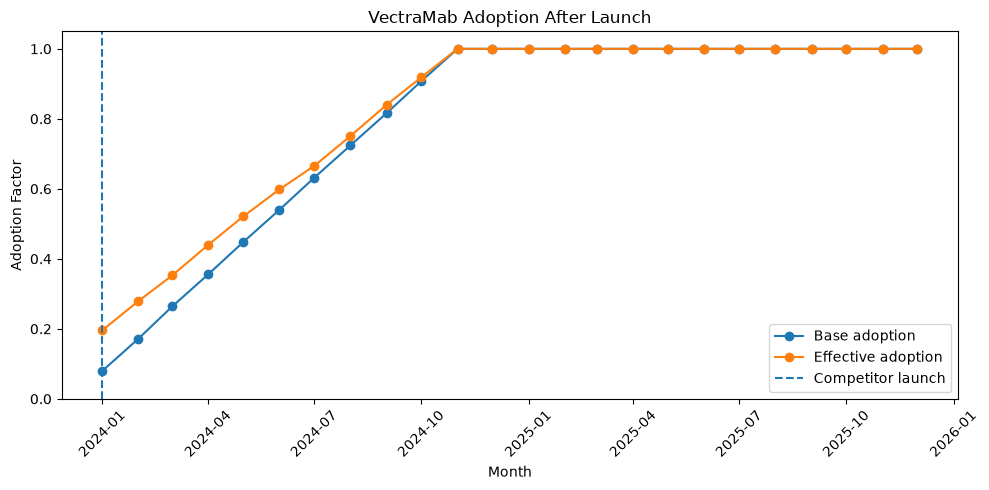

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    competitor_adoption["month"],
    competitor_adoption["base_adoption_factor"],
    marker="o",
    label="Base adoption",
)

plt.plot(
    competitor_adoption["month"],
    competitor_adoption["effective_adoption_factor"],
    marker="o",
    label="Effective adoption",
)

plt.axvline(
    launch_date,
    linestyle="--",
    label="Competitor launch",
)

plt.title(f"{competitor_name} Adoption After Launch")
plt.xlabel("Month")
plt.ylabel("Adoption Factor")
plt.ylim(0, 1.05)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpreting the Adoption Curve

VectraMab's effective adoption is higher than its base adoption during the early launch period because promotional activity accelerates uptake.

As the product approaches full adoption:

- the remaining adoption gap becomes smaller
- promotional acceleration declines
- the effective adoption factor converges toward `1.0`

Adoption describes product maturity. It does not directly equal market share.

## Market Share Before and After Competitive Entry

A competitor launch changes the entire market, not only the new entrant.

VectraMab is configured to source its gained share primarily from OncoNova:

```yaml
share_source_weights:
  P001: 0.70
  P002: 0.30
```

This means the market leader is expected to experience greater displacement than the secondary incumbent.

In [11]:
market_share_named = market_share.merge(
    products[
        [
            "product_id",
            "product_name",
        ]
    ],
    on="product_id",
    how="left",
)

market_share_plot = market_share_named.pivot(
    index="month",
    columns="product_name",
    values="adjusted_market_share",
)

market_share_plot.head()

product_name,OncoNova,Tumora,VectraMab
month,,,
2023-01-01,0.611270,0.388730,0.0
2023-02-01,0.608827,0.391173,0.0
2023-03-01,0.614372,0.385628,0.0
2023-04-01,0.611444,0.388556,0.0
2023-05-01,0.619905,0.380095,0.0


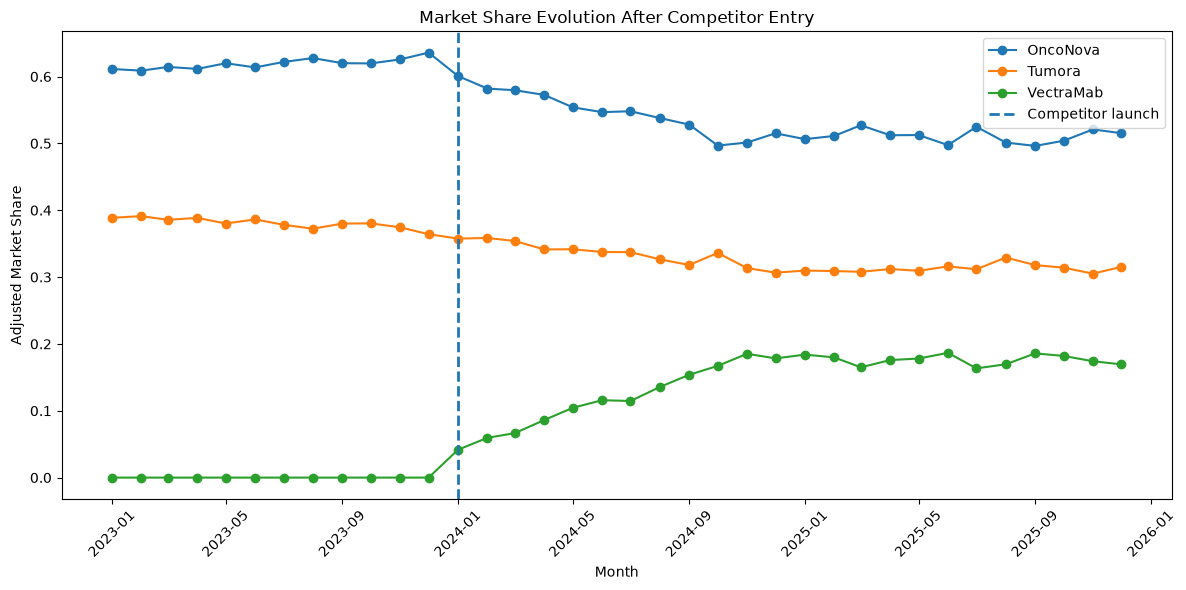

In [12]:
plt.figure(figsize=(12, 6))

for product_name in market_share_plot.columns:
    plt.plot(
        market_share_plot.index,
        market_share_plot[product_name],
        marker="o",
        label=product_name,
    )

plt.axvline(
    launch_date,
    linestyle="--",
    linewidth=2,
    label="Competitor launch",
)

plt.title("Market Share Evolution After Competitor Entry")
plt.xlabel("Month")
plt.ylabel("Adjusted Market Share")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations

The market-share trend shows several connected effects:

- VectraMab remains at zero before launch.
- It gains share gradually after January 2024.
- OncoNova loses more share than Tumora.
- Market shares continue to sum to 100% every month.
- Month-to-month movement is not perfectly smooth because promotion and market noise continue to affect all products.

This is the difference between generating an isolated launch curve and simulating a competitive market response.

In [13]:
comparison_months = [
    launch_date - pd.DateOffset(months=1),
    launch_date + pd.DateOffset(months=5),
    launch_date + pd.DateOffset(months=10),
]

share_comparison = market_share_named[market_share_named["month"].isin(comparison_months)].pivot(
    index="product_name",
    columns="month",
    values="adjusted_market_share",
)

share_comparison

month,2023-12-01,2024-06-01,2024-11-01
product_name,,,
OncoNova,0.635845,0.546739,0.501269
Tumora,0.364155,0.337495,0.313459
VectraMab,0.000000,0.115766,0.185272


## Measuring Incumbent Displacement

A new competitor's success should not be evaluated only through its own market-share growth.

Commercial analysts should also ask:

- which incumbent loses the most?
- how quickly does displacement occur?
- does the market leader remain dominant?
- does the secondary incumbent hold its position?
- does the new entrant reach its expected mature share?

In [14]:
pre_launch_month = launch_date - pd.DateOffset(months=1)
post_launch_month = launch_date + pd.DateOffset(months=5)

incumbent_change = (
    market_share_named[
        market_share_named["month"].isin(
            [
                pre_launch_month,
                post_launch_month,
            ]
        )
    ]
    .pivot(
        index="product_name",
        columns="month",
        values="adjusted_market_share",
    )
    .rename(
        columns={
            pre_launch_month: "pre_launch_share",
            post_launch_month: "post_launch_share",
        }
    )
)

incumbent_change["share_change"] = (
    incumbent_change["post_launch_share"] - incumbent_change["pre_launch_share"]
)

incumbent_change

month,pre_launch_share,post_launch_share,share_change
product_name,,,
OncoNova,0.635845,0.546739,-0.089106
Tumora,0.364155,0.337495,-0.026660
VectraMab,0.000000,0.115766,0.115766


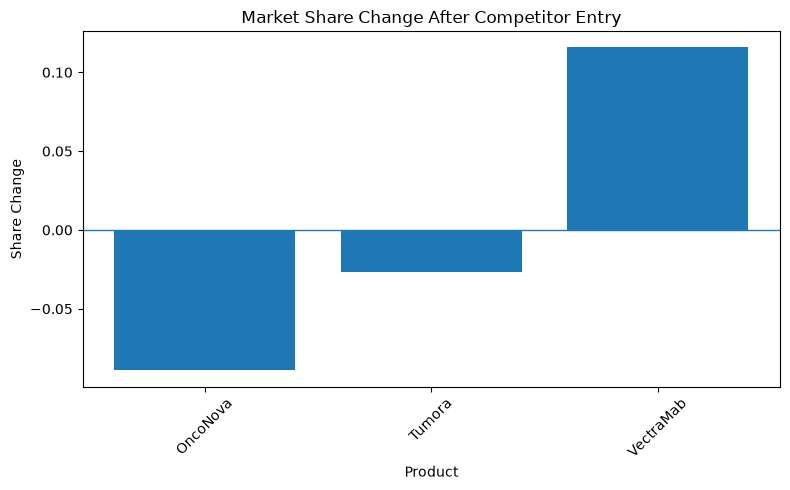

In [15]:
share_change_plot = incumbent_change["share_change"].sort_values().reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    share_change_plot["product_name"],
    share_change_plot["share_change"],
)

plt.axhline(0, linewidth=1)

plt.title("Market Share Change After Competitor Entry")
plt.xlabel("Product")
plt.ylabel("Share Change")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Prescription Impact

Adjusted market share drives product-level prescription allocation:

```text
Monthly Market Demand
        ×
Adjusted Market Share
        =
Product NRx
        ↓
Allocated Across HCPs
```

As VectraMab gains share, it receives more of the available market demand.

Incumbent products receive less of that demand, with the largest effect expected for the product most exposed to competitive displacement.

In [16]:
rx_named = prescriptions.merge(
    products[
        [
            "product_id",
            "product_name",
        ]
    ],
    on="product_id",
    how="left",
)

monthly_rx = (
    rx_named.groupby(
        [
            "rx_date",
            "product_name",
        ]
    )["nrx"]
    .sum()
    .reset_index()
)

monthly_rx.head()

,rx_date,product_name,nrx
0,2023-01-01,OncoNova,401
1,2023-01-01,Tumora,262
2,2023-01-01,VectraMab,0
3,2023-02-01,OncoNova,405
4,2023-02-01,Tumora,279


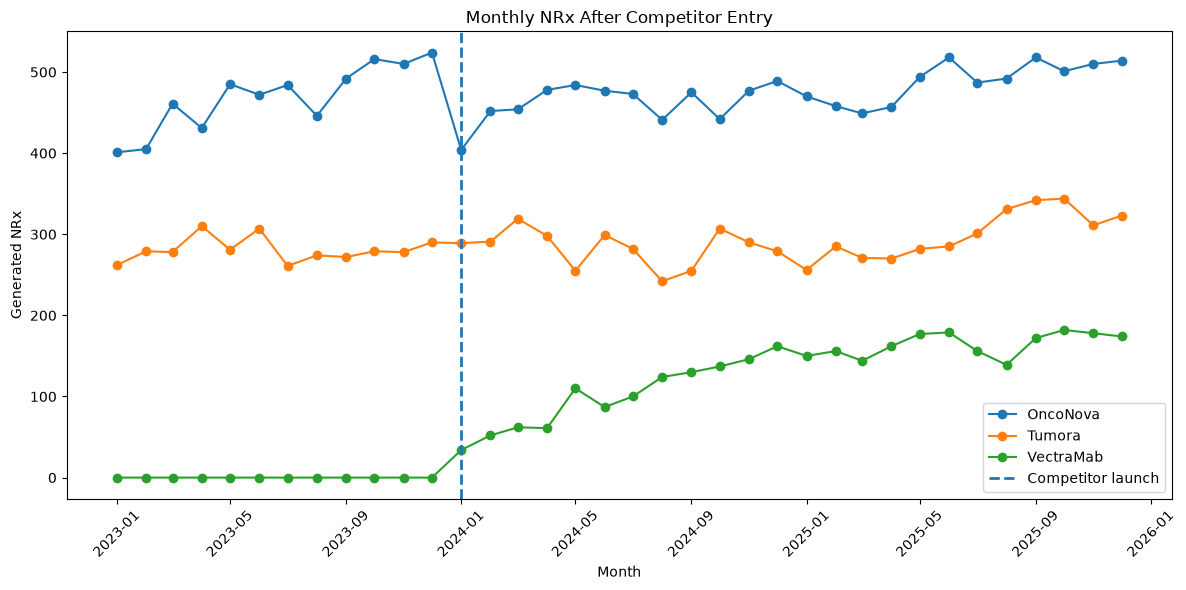

In [17]:
rx_plot = monthly_rx.pivot(
    index="rx_date",
    columns="product_name",
    values="nrx",
)

plt.figure(figsize=(12, 6))

for product_name in rx_plot.columns:
    plt.plot(
        rx_plot.index,
        rx_plot[product_name],
        marker="o",
        label=product_name,
    )

plt.axvline(
    launch_date,
    linestyle="--",
    linewidth=2,
    label="Competitor launch",
)

plt.title("Monthly NRx After Competitor Entry")
plt.xlabel("Month")
plt.ylabel("Generated NRx")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Prescription Volume and Competitive Position

Absolute NRx may not move perfectly in line with market share each month.

This is because prescription volume depends on both:

- adjusted market share
- total market demand

A product can lose share while temporarily gaining prescriptions if the market grows quickly enough.

Competitive performance should therefore be evaluated using both relative share and absolute prescription volume.

## Demand Reconciliation

Competitor entry changes how market demand is distributed across products.

It should not create additional unexplained prescriptions.

For every month:

```text
Total Generated NRx
        =
Simulated Market NRx
```

In [18]:
market_demand["month"] = pd.to_datetime(market_demand["month"])

monthly_generated_nrx = (
    prescriptions.groupby("rx_date")["nrx"]
    .sum()
    .reset_index(name="generated_nrx")
    .rename(columns={"rx_date": "month"})
)

monthly_generated_nrx["month"] = pd.to_datetime(monthly_generated_nrx["month"])

demand_reconciliation = market_demand[
    [
        "month",
        "market_nrx",
    ]
].merge(
    monthly_generated_nrx,
    on="month",
    how="left",
)

demand_reconciliation["difference"] = (
    demand_reconciliation["generated_nrx"] - demand_reconciliation["market_nrx"]
)

demand_reconciliation.head()

,month,market_nrx,generated_nrx,difference
0,2023-01-01,663,663,0
1,2023-02-01,684,684,0
2,2023-03-01,739,739,0
3,2023-04-01,741,741,0
4,2023-05-01,766,766,0


In [19]:
assert (demand_reconciliation["difference"] == 0).all()

print("Monthly generated NRx reconciles exactly with simulated market demand.")

Monthly generated NRx reconciles exactly with simulated market demand.


> **Business Insight**
>
> Competitor launch analysis is not only about whether the new entrant grows.
>
> It is also about how the market responds.
>
> Analysts should evaluate:
>
> - speed of competitor adoption
> - promotional acceleration
> - market-leader vulnerability
> - relative resilience of incumbents
> - prescription reallocation
> - whether market growth masks competitive loss
>
> A competitor can gain meaningful share without immediately becoming the market leader.

## Key Takeaways

- A competitor remains commercially inactive before its launch date.
- Adoption develops gradually after entry.
- Promotion can accelerate uptake during the early launch period.
- Competitor share is sourced from existing products.
- The market leader may experience greater displacement than smaller incumbents.
- Market-share movement flows through to prescription allocation.
- Absolute NRx and relative market share should be interpreted together.
- Monthly generated NRx remains fully reconciled with total market demand.

This scenario demonstrates a broader HealthSynth principle:

```text
Define the competitive market
        ↓
Introduce a commercial event
        ↓
Simulate market response
        ↓
Generate internally consistent datasets
        ↓
Analyse the outcomes
```